<a href="https://colab.research.google.com/github/hongocphuongnhu/TH_Deep_Learning/blob/main/Tuan03_THDeep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Kích thước dữ liệu gốc:")
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

Kích thước dữ liệu gốc:
(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


In [ ]:
# Reshape dữ liệu thành 2D array
X_train = X_train.reshape(50000, 3072)
X_test = X_test.reshape(10000, 3072)

# Feature scaling
# dùng MinMaxScaler để đưa giá trị pixel về khoảng [0, 1]
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes: ', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes:  10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
# Khởi tạo mô hình
model = Sequential()

# Thêm hidden layer đầu tiên với hàm kích hoạt ReLU
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Thêm hidden layer thứ hai
model.add(Dense(units=128, kernel_initializer='uniform', activation='relu'))

# Thêm output layer với hàm softmax
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Compile neural network với Optimizer Adam và hàm Loss để đánh giá
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện mô hình
model_fit = model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.3279 - loss: 1.8453 - val_accuracy: 0.3706 - val_loss: 1.7843
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.3990 - loss: 1.6777 - val_accuracy: 0.3948 - val_loss: 1.7076
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.4291 - loss: 1.5959 - val_accuracy: 0.4426 - val_loss: 1.5651
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.4442 - loss: 1.5487 - val_accuracy: 0.4302 - val_loss: 1.5749
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.4584 - loss: 1.5070 - val_accuracy: 0.4444 - val_loss: 1.5828
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.4680 - loss: 1.4802 - val_accuracy: 0.4392 - val_loss: 1.5597
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.4812 - loss: 1.4502 - val_accuracy: 0.4648 - val_loss: 1.5020
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.4895 -

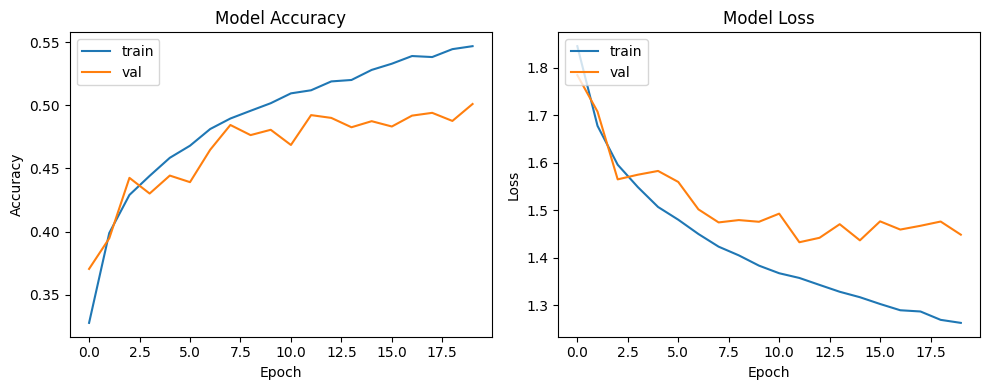

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Nhãn dự đoán: 3
Nhãn thực tế: 3


In [ ]:
# Vẽ biểu đồ Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')

# Vẽ biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.tight_layout()
plt.show()

# Dự báo thử 1 ảnh mới trong tập test
print("Nhãn dự đoán:", np.argmax(model.predict(X_test)[0]))
print("Nhãn thực tế:", y_test[0][0])

In [ ]:
#BÀI 2: MNIST
# Đọc dữ liệu MNIST
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()

print('X_train shape:', X_train_mnist.shape)   # (60000, 28, 28)
print('X_test shape :', X_test_mnist.shape)
print('Classes      :', np.unique(y_train_mnist))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
X_test shape : (10000, 28, 28)
Classes      : [0 1 2 3 4 5 6 7 8 9]


In [ ]:
#Tiền xử lý
X_train_mnist_flat = X_train_mnist.reshape(60000, 784).astype('float32') / 255.0
X_test_mnist_flat  = X_test_mnist.reshape(10000, 784).astype('float32') / 255.0

print('X_train_flat shape:', X_train_mnist_flat.shape)

X_train_flat shape: (60000, 784)


In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout

#Xây dựng mô hình ANN
mnist_model = Sequential([
    Dense(256, input_shape=(784,), kernel_initializer='uniform', activation='relu'),
    Dropout(0.2),
    Dense(128, kernel_initializer='uniform', activation='relu'),
    Dense(10,  kernel_initializer='uniform', activation='softmax')
])

mnist_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mnist_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Huấn luyện MNIST model
mnist_fit = mnist_model.fit(
    X_train_mnist_flat, y_train_mnist,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8842 - loss: 0.4145 - val_accuracy: 0.9565 - val_loss: 0.1516
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9515 - loss: 0.1624 - val_accuracy: 0.9720 - val_loss: 0.1005
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9648 - loss: 0.1158 - val_accuracy: 0.9728 - val_loss: 0.0915
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9729 - loss: 0.0877 - val_accuracy: 0.9767 - val_loss: 0.0766
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9773 - loss: 0.0709 - val_accuracy: 0.9748 - val_loss: 0.0798
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9801 - loss: 0.0609 - val_accuracy: 0.9785 - val_loss: 0.0717
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9842 - loss: 0.0494 - val_accuracy: 0.9810 - val_loss: 0.0667
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9852 - loss: 0.0446 - val_accuracy: 

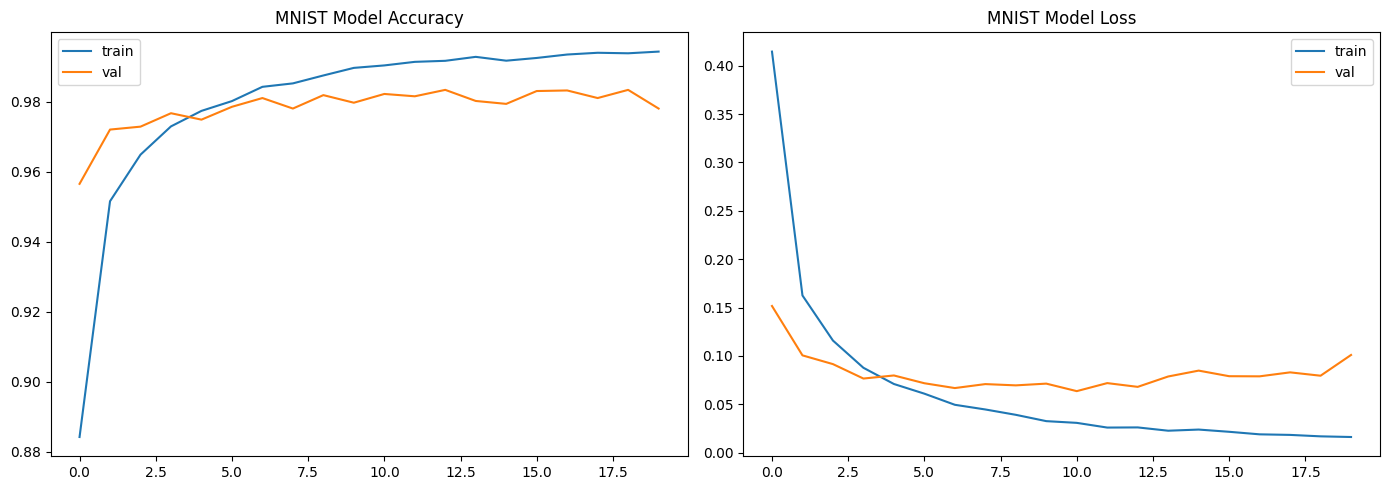

Test Accuracy: 0.9775 | Test Loss: 0.0857


In [ ]:
#Đánh giá model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(mnist_fit.history['accuracy'], label='train')
ax1.plot(mnist_fit.history['val_accuracy'], label='val')
ax1.set_title('MNIST Model Accuracy'); ax1.legend()

ax2.plot(mnist_fit.history['loss'], label='train')
ax2.plot(mnist_fit.history['val_loss'], label='val')
ax2.set_title('MNIST Model Loss'); ax2.legend()
plt.tight_layout(); plt.show()

test_loss, test_acc = mnist_model.evaluate(X_test_mnist_flat, y_test_mnist, verbose=0)
print(f'Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted: [7 2 1 0 4 1 4 9 5 9]
True     : [7 2 1 0 4 1 4 9 5 9]


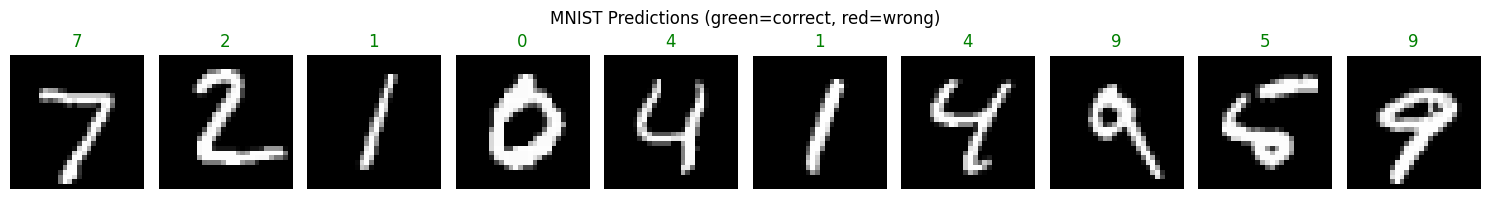

In [ ]:
#Dự báo (MNIST)
preds_mnist = np.argmax(mnist_model.predict(X_test_mnist_flat[:10]), axis=1)
print('Predicted:', preds_mnist)
print('True     :', y_test_mnist[:10])

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_test_mnist[i], cmap='gray')
    color = 'green' if preds_mnist[i] == y_test_mnist[i] else 'red'
    ax.set_title(str(preds_mnist[i]), color=color)
    ax.axis('off')
plt.suptitle('MNIST Predictions (green=correct, red=wrong)')
plt.tight_layout(); plt.show()

In [ ]:
#BÀI 4: ADULT INCOME
col_names = ['age','workclass','fnlwgt','education','education_num',
             'marital_status','occupation','relationship','race','sex',
             'capital_gain','capital_loss','hours_per_week','native_country','income']

adult = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',
    names=col_names, sep=', ', engine='python', na_values='?'
)

print('Shape:', adult.shape)
adult.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Thu nhập phân bố:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


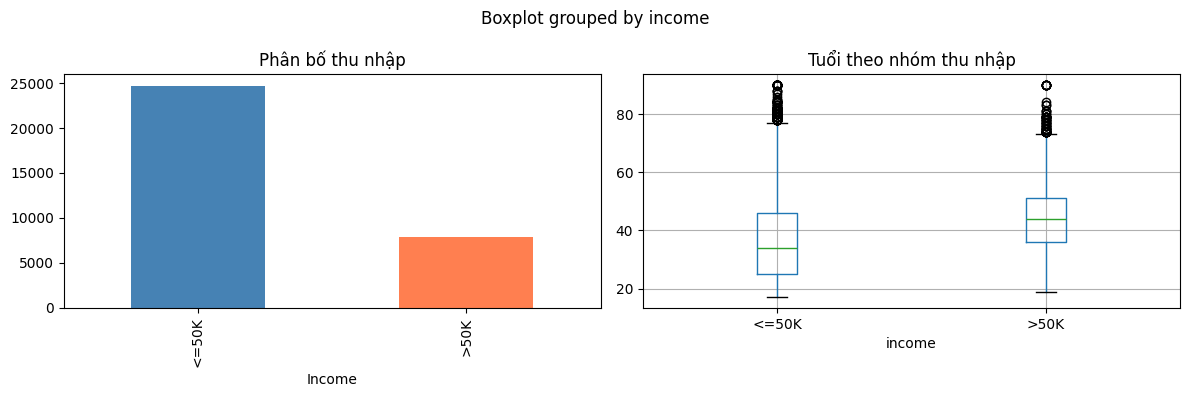

In [ ]:
print('Thu nhập phân bố:')
print(adult['income'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
adult['income'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','coral'])
axes[0].set_title('Phân bố thu nhập'); axes[0].set_xlabel('Income')

adult.boxplot(column='age', by='income', ax=axes[1])
axes[1].set_title('Tuổi theo nhóm thu nhập')
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

#Tiền xử lý dữ liệu
adult_clean = adult.dropna().copy()

# Encode categorical columns
cat_cols = ['workclass','education','marital_status','occupation',
            'relationship','race','sex','native_country']

le = LabelEncoder()
for col in cat_cols:
    adult_clean[col] = le.fit_transform(adult_clean[col])

# Encode nhãn: <=50K → 0, >50K → 1
adult_clean['income'] = (adult_clean['income'] == '>50K').astype(int)

X_adult = adult_clean.drop('income', axis=1).values
y_adult = adult_clean['income'].values

# Feature scaling
scaler_adult = MinMaxScaler()
X_adult = scaler_adult.fit_transform(X_adult)

# Tách train/test
X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(
    X_adult, y_adult, test_size=0.2, random_state=42
)

print('Train size:', X_train_adult.shape)
print('Test  size:', X_test_adult.shape)
print('Features  :', X_train_adult.shape[1])

Train size: (24129, 14)
Test  size: (6033, 14)
Features  : 14


In [ ]:
#Xây dựng ANN
adult_model = Sequential([
    Dense(64, input_dim=X_train_adult.shape[1],
          kernel_initializer='uniform', activation='relu'),
    Dropout(0.3),
    Dense(32, kernel_initializer='uniform', activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')   # binary output
])

adult_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
adult_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Huấn luyện
adult_fit = adult_model.fit(
    X_train_adult, y_train_adult,
    validation_split=0.1,
    epochs=30,
    batch_size=256,
    verbose=1
)

Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7516 - loss: 0.5667 - val_accuracy: 0.7522 - val_loss: 0.4949
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7718 - loss: 0.4720 - val_accuracy: 0.8090 - val_loss: 0.4390
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8026 - loss: 0.4314 - val_accuracy: 0.8160 - val_loss: 0.4022
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8118 - loss: 0.4064 - val_accuracy: 0.8264 - val_loss: 0.3828
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8211 - loss: 0.3890 - val_accuracy: 0.8284 - val_loss: 0.3689
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8241 - loss: 0.3767 - val_accuracy: 0.8288 - val_loss: 0.3731
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8305 - loss: 0.3695 - val_accuracy: 0.8305 - val_loss: 0.3549
Epoch 8/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8320 - loss: 0.3614 - val_accuracy: 0.8255 - val_loss:

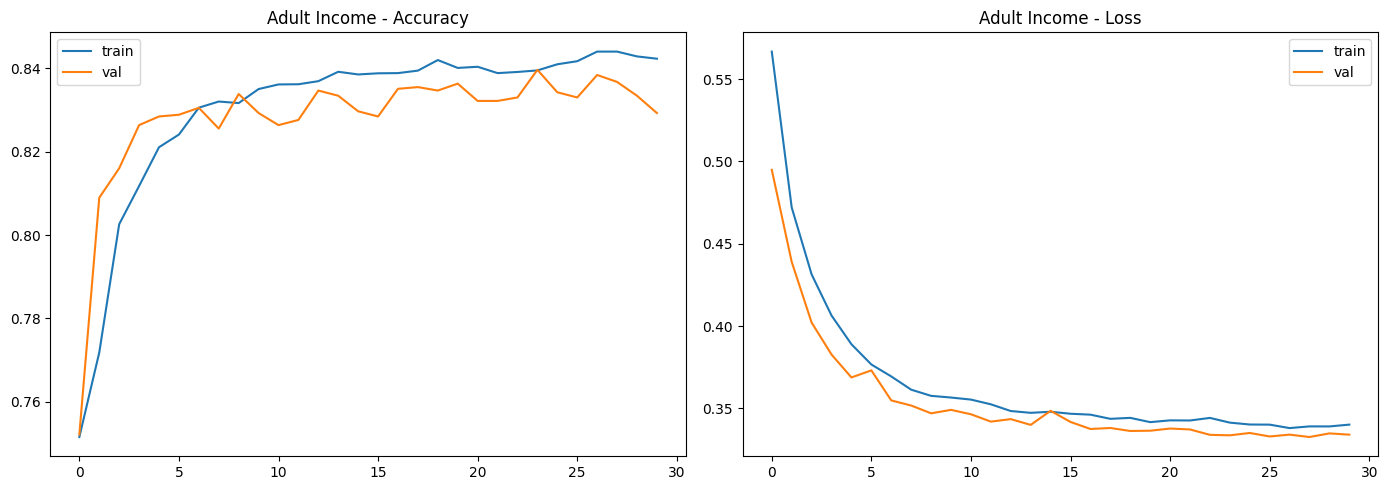

189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy: 0.8488314271506713

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      4503
        >50K       0.74      0.63      0.68      1530

    accuracy                           0.85      6033
   macro avg       0.81      0.78      0.79      6033
weighted avg       0.84      0.85      0.84      6033



In [ ]:
from sklearn.metrics import accuracy_score, classification_report

#Đánh giá Adult Model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(adult_fit.history['accuracy'], label='train')
ax1.plot(adult_fit.history['val_accuracy'], label='val')
ax1.set_title('Adult Income - Accuracy'); ax1.legend()

ax2.plot(adult_fit.history['loss'], label='train')
ax2.plot(adult_fit.history['val_loss'], label='val')
ax2.set_title('Adult Income - Loss'); ax2.legend()
plt.tight_layout(); plt.show()

y_pred_adult = (adult_model.predict(X_test_adult) > 0.5).astype(int).flatten()
print('Test Accuracy:', accuracy_score(y_test_adult, y_pred_adult))
print('\nClassification Report:')
print(classification_report(y_test_adult, y_pred_adult,
                            target_names=['<=50K', '>50K']))

In [ ]:
# Dự báo người mới
# Ví dụ 1 mẫu từ tập test
sample_idx = 0
sample_input = X_test_adult[sample_idx].reshape(1, -1)
prob = adult_model.predict(sample_input)[0][0]
pred_class = '>50K' if prob > 0.5 else '<=50K'
true_class = '>50K' if y_test_adult[sample_idx] == 1 else '<=50K'
print(f'Xác suất >50K: {prob:.4f}')
print(f'Dự báo: {pred_class} | Thực tế: {true_class}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Xác suất >50K: 0.2140
Dự báo: <=50K | Thực tế: >50K
